# 🎲 Nelson-Siegel Bayesiano con MCMC
## De la intuición al código: Metropolis-Hastings y NUTS en PyMC

Este notebook cubre **dos pasos fundamentales** del proyecto DNS-Bayesiano:

| Parte | Método | Propósito |
|-------|--------|-----------|
| **I** | Metropolis-Hastings (manual, NumPy puro) | Entender MCMC desde adentro — burn-in visible, exploración explícita |
| **II** | NUTS + numpyro (PyMC) | Producción eficiente — análisis de trazas, diagnósticos, resúmenes |

### El modelo Nelson-Siegel

$$y(\tau) = \underbrace{\beta_0}_{\text{nivel}} + \underbrace{\beta_1 \frac{1 - e^{-\lambda\tau}}{\lambda\tau}}_{\text{pendiente}} + \underbrace{\beta_2 \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)}_{\text{curvatura}} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

**¿Por qué Bayesiano?** OLS estima $\beta_0, \beta_1, \beta_2$ condicionado a $\lambda$ fijo. Bayesiano estima **todos los parámetros simultáneamente**, incluyendo $\lambda$, y produce **distribuciones completas de incertidumbre**.


## ⚖️ El Marco Bayesiano

El punto de partida es el **Teorema de Bayes** aplicado a parámetros:

$$\underbrace{p(\theta \mid y)}_{\text{posterior}} \propto \underbrace{p(y \mid \theta)}_{\text{verosimilitud}} \cdot \underbrace{p(\theta)}_{\text{prior}}$$

Para NS tenemos $\theta = (\beta_0, \beta_1, \beta_2, \lambda, \sigma)$ y la posterior es:

$$p(\beta_0, \beta_1, \beta_2, \lambda, \sigma \mid y) \propto \underbrace{\prod_{j=1}^{J} \mathcal{N}(y_j \mid \mu(\tau_j, \theta), \sigma^2)}_{\text{verosimilitud NS}} \cdot \underbrace{p(\beta_0) \cdot p(\beta_1) \cdot p(\beta_2) \cdot p(\lambda) \cdot p(\sigma)}_{\text{priors}}$$

**El problema**: esta posterior no tiene forma analítica cerrada porque $\lambda$ aparece de forma no lineal. La solución es **MCMC** — construir una cadena de Markov cuya distribución estacionaria sea exactamente la posterior.


In [1]:
# ── Instalación (solo primera vez) ──────────────────────────────────
# !pip install pymc numpyro jax jaxlib arviz scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # para organizar subplots de manera flexible
from matplotlib.patches import FancyArrowPatch # para dibujar flechas personalizadas en el grafo probabilístico
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

import pymc as pm
import arviz as az

# Estilo visual consistente
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "burnin":   "#FF6B6B",
    "postburn": "#4ECDC4",
    "mean":     "#FFE66D",
    "hdi":      "#95E1D3",
    "chain":    ["#2196F3", "#E91E63", "#4CAF50", "#FF9800"],
    "kde":      "#1A1A2E",
}

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")


PyMC version: 5.28.1
ArviZ version: 0.23.4


## 📊 Datos

Usamos rendimientos del Tesoro de EEUU para una única fecha (valores representativos de 2024).  
Esto nos permite enfocarnos **100% en el proceso MCMC** sin preocuparnos por la fuente de datos.  
Cuando pasemos al proyecto TES Colombia, solo cambia el vector `yields` y `maturities`.


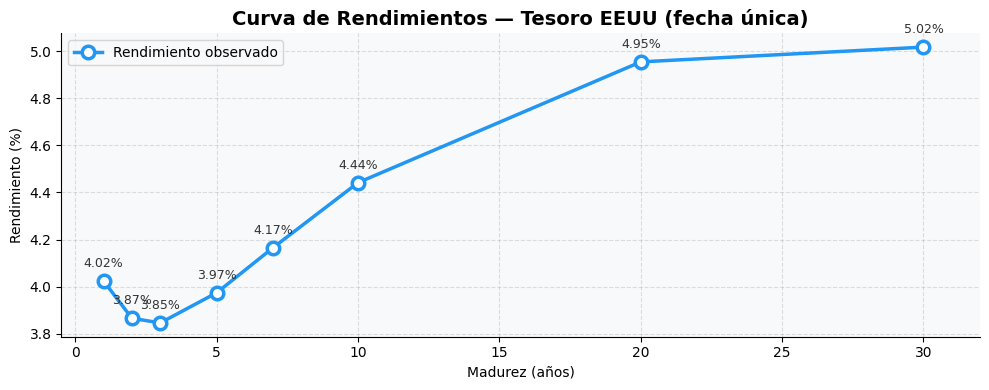

Vencimientos: [1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
Rendimientos (%): [4.0236, 3.8663, 3.8465, 3.9746, 4.1665, 4.4417, 4.954, 5.0166]


In [2]:
# Vencimientos en años
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

# Rendimientos observados (% → decimal)
yields_pct = np.array([4.0236, 3.8663, 3.8465, 3.9746, 4.1665, 4.4417, 4.9540, 5.0166])
yields = yields_pct / 100.0  # trabajamos en decimal

# ── Visualización de la curva observada ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(maturities, yields_pct, "o-", color="#2196F3", markersize=9,
        linewidth=2.5, markerfacecolor="white", markeredgewidth=2.5, label="Rendimiento observado")
for m, y in zip(maturities, yields_pct):
    ax.annotate(f"{y:.2f}%", (m, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color="#333333")
ax.set_title("Curva de Rendimientos — Tesoro EEUU (fecha única)", fontsize=14, fontweight="bold")
ax.set_xlabel("Madurez (años)")
ax.set_ylabel("Rendimiento (%)")
ax.set_xlim(-0.5, 32)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Vencimientos: {maturities.tolist()}")
print(f"Rendimientos (%): {yields_pct.tolist()}")


---
# PARTE I — Metropolis-Hastings Manual 🔧

## Algoritmo Metropolis-Hastings

MH es el MCMC más simple. En cada iteración:

1. **Propuesta**: $\theta^* = \theta_t + \epsilon$, donde $\epsilon \sim \mathcal{N}(0, \Sigma_{\text{step}})$
2. **Ratio de aceptación**: $\alpha = \min\left(1, \frac{p(\theta^* \mid y)}{p(\theta_t \mid y)}\right)$
3. **Decisión**: Con probabilidad $\alpha$ mueve a $\theta^*$; si no, se queda en $\theta_t$

**Burn-in (calentamiento)**: Las primeras iteraciones dependen del punto inicial y no son representativas de la posterior. Se descartan. El número de iteraciones hasta que la cadena "se olvida" del punto inicial se llama **burn-in** o **período de calentamiento**.

$$\underbrace{\theta_0, \theta_1, \ldots, \theta_{B}}_{\text{burn-in (descartar)}}, \underbrace{\theta_{B+1}, \ldots, \theta_{N}}_{\text{muestras válidas de }p(\theta \mid y)}$$

### Priors del modelo NS

| Parámetro | Prior | Justificación |
|-----------|-------|---------------|
| $\beta_0$ | $\mathcal{N}(0.05, 0.05^2)$ | Nivel típico de tasas ~5%, amplio |
| $\beta_1$ | $\mathcal{N}(-0.01, 0.05^2)$ | Pendiente puede ser negativa o positiva |
| $\beta_2$ | $\mathcal{N}(0.04, 0.05^2)$ | Curvatura, puede ser positiva o negativa |
| $\lambda$ | $\text{Beta}(12, 14)$ | Confinado a $(0,1)$, moda ≈ 0.46 (literatura) |
| $\sigma$ | $\mathcal{HN}(0.01)$ | Error pequeño en escala decimal |


In [3]:
# ── Función Nelson-Siegel ────────────────────────────────────────────
def ns_curve(tau, beta0, beta1, beta2, lam):
    """Curva NS en escala decimal. Evita división por cero con clip."""
    lam_tau = np.maximum(lam * tau, 1e-10)
    term1 = (1 - np.exp(-lam_tau)) / lam_tau
    term2 = term1 - np.exp(-lam_tau)
    return beta0 + beta1 * term1 + beta2 * term2


# ── Log-prior ────────────────────────────────────────────────────────
def log_prior(params):
    beta0, beta1, beta2, lam, sigma = params

    # beta ~ Normal
    lp  = stats.norm.logpdf(beta0, 0.05, 0.05)
    lp += stats.norm.logpdf(beta1, -0.01, 0.05)
    lp += stats.norm.logpdf(beta2, 0.04, 0.05)

    # lambda ~ Beta(12, 14) en (0, 1)
    if lam <= 0 or lam >= 1:
        return -np.inf
    lp += stats.beta.logpdf(lam, 12, 14)

    # sigma ~ HalfNormal(0.01)
    if sigma <= 0:
        return -np.inf
    lp += stats.halfnorm.logpdf(sigma, scale=0.01)

    return lp


# ── Log-verosimilitud ─────────────────────────────────────────────────
def log_likelihood(params, tau, y_obs):
    beta0, beta1, beta2, lam, sigma = params
    if sigma <= 0 or lam <= 0 or lam >= 1:
        return -np.inf
    mu = ns_curve(tau, beta0, beta1, beta2, lam)
    return np.sum(stats.norm.logpdf(y_obs, mu, sigma))


# ── Log-posterior ─────────────────────────────────────────────────────
def log_posterior(params, tau, y_obs):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(params, tau, y_obs)
    return lp + ll


# ── Prueba rápida ─────────────────────────────────────────────────────
theta_test = [0.05, -0.01, 0.04, 0.46, 0.002]
lp_test = log_posterior(theta_test, maturities, yields)
print(f"Log-posterior en valores iniciales: {lp_test:.4f}")
print("(Debe ser un número finito negativo — ✓)" if np.isfinite(lp_test) else "⚠ Problema en el log-posterior")


Log-posterior en valores iniciales: -112.6178
(Debe ser un número finito negativo — ✓)


In [4]:
def metropolis_hastings(log_post_fn, init, n_iter, step_sizes, tau, y_obs, seed=42):
    """
    Metropolis-Hastings con propuesta Gaussiana diagonal.

    Parámetros
    ----------
    log_post_fn : callable — log-posterior(params, tau, y_obs)
    init        : array-like — punto inicial
    n_iter      : int — número total de iteraciones
    step_sizes  : array-like — desviación estándar de la propuesta por parámetro
    seed        : int — semilla para reproducibilidad

    Devuelve
    --------
    samples  : ndarray (n_iter, n_params)
    accepted : float — tasa de aceptación global
    log_posts: ndarray (n_iter,) — log-posterior en cada iteración
    """
    rng = np.random.default_rng(seed)
    n_params = len(init)
    samples   = np.zeros((n_iter, n_params))
    log_posts = np.zeros(n_iter)
    accepted  = 0

    current    = np.array(init, dtype=float)
    current_lp = log_post_fn(current, tau, y_obs)

    for i in range(n_iter):
        # Propuesta: salto Gaussiano
        proposal    = current + rng.standard_normal(n_params) * step_sizes
        proposal_lp = log_post_fn(proposal, tau, y_obs)

        # Criterio de aceptación (en escala log)
        log_alpha = proposal_lp - current_lp
        if np.log(rng.random()) < log_alpha:
            current    = proposal
            current_lp = proposal_lp
            accepted  += 1

        samples[i]   = current
        log_posts[i] = current_lp

    return samples, accepted / n_iter, log_posts


# Parámetros del sampler
INIT       = [0.06, -0.02, 0.05, 0.50, 0.003]   # punto de inicio
STEP_SIZES = [0.003, 0.003, 0.003, 0.015, 0.0003] # tamaño de paso por parámetro
N_BURNIN   = 3_000
N_SAMPLES  = 10_000
N_TOTAL    = N_BURNIN + N_SAMPLES

print(f"Corriendo MH: {N_TOTAL:,} iteraciones totales")
print(f"  Burn-in: {N_BURNIN:,}  |  Muestras post burn-in: {N_SAMPLES:,}")
print(f"  Punto inicial: {INIT}")


Corriendo MH: 13,000 iteraciones totales
  Burn-in: 3,000  |  Muestras post burn-in: 10,000
  Punto inicial: [0.06, -0.02, 0.05, 0.5, 0.003]


In [5]:
# ── Correr el sampler ────────────────────────────────────────────────
samples_mh, accept_rate, log_posts_mh = metropolis_hastings(
    log_post_fn = log_posterior,
    init        = INIT,
    n_iter      = N_TOTAL,
    step_sizes  = STEP_SIZES,
    tau         = maturities,
    y_obs       = yields,
    seed        = 2024
)

# Separar burn-in de muestras válidas
samples_burnin = samples_mh[:N_BURNIN]
samples_post   = samples_mh[N_BURNIN:]

print(f"✓ MH completado")
print(f"  Tasa de aceptación: {accept_rate:.1%}  (objetivo: 20%-50% para MH)")
print(f"  Muestras válidas: {samples_post.shape}")

PARAM_NAMES  = ["β₀  (Nivel)", "β₁  (Pendiente)", "β₂  (Curvatura)", "λ   (Decaimiento)", "σ   (Error)"]
PARAM_KEYS   = ["beta0", "beta1", "beta2", "lambda", "sigma"]


✓ MH completado
  Tasa de aceptación: 7.2%  (objetivo: 20%-50% para MH)
  Muestras válidas: (10000, 5)


### 🔍 Visualización de Trazas con Burn-in

**Cómo leer estos gráficos:**

- **Panel izquierdo** — Cadena completa: la zona roja es el burn-in, la azul son las muestras válidas. La línea naranja es la media acumulada — cuando se estabiliza, la cadena convergió.
- **Panel central** — Zoom post burn-in: muestra la "mezcla" de la cadena. Queremos ruido blanco (sin tendencias), con la cadena cruzando su media frecuentemente.
- **Panel derecho** — Distribución posterior: histograma + KDE + HDI 95%.


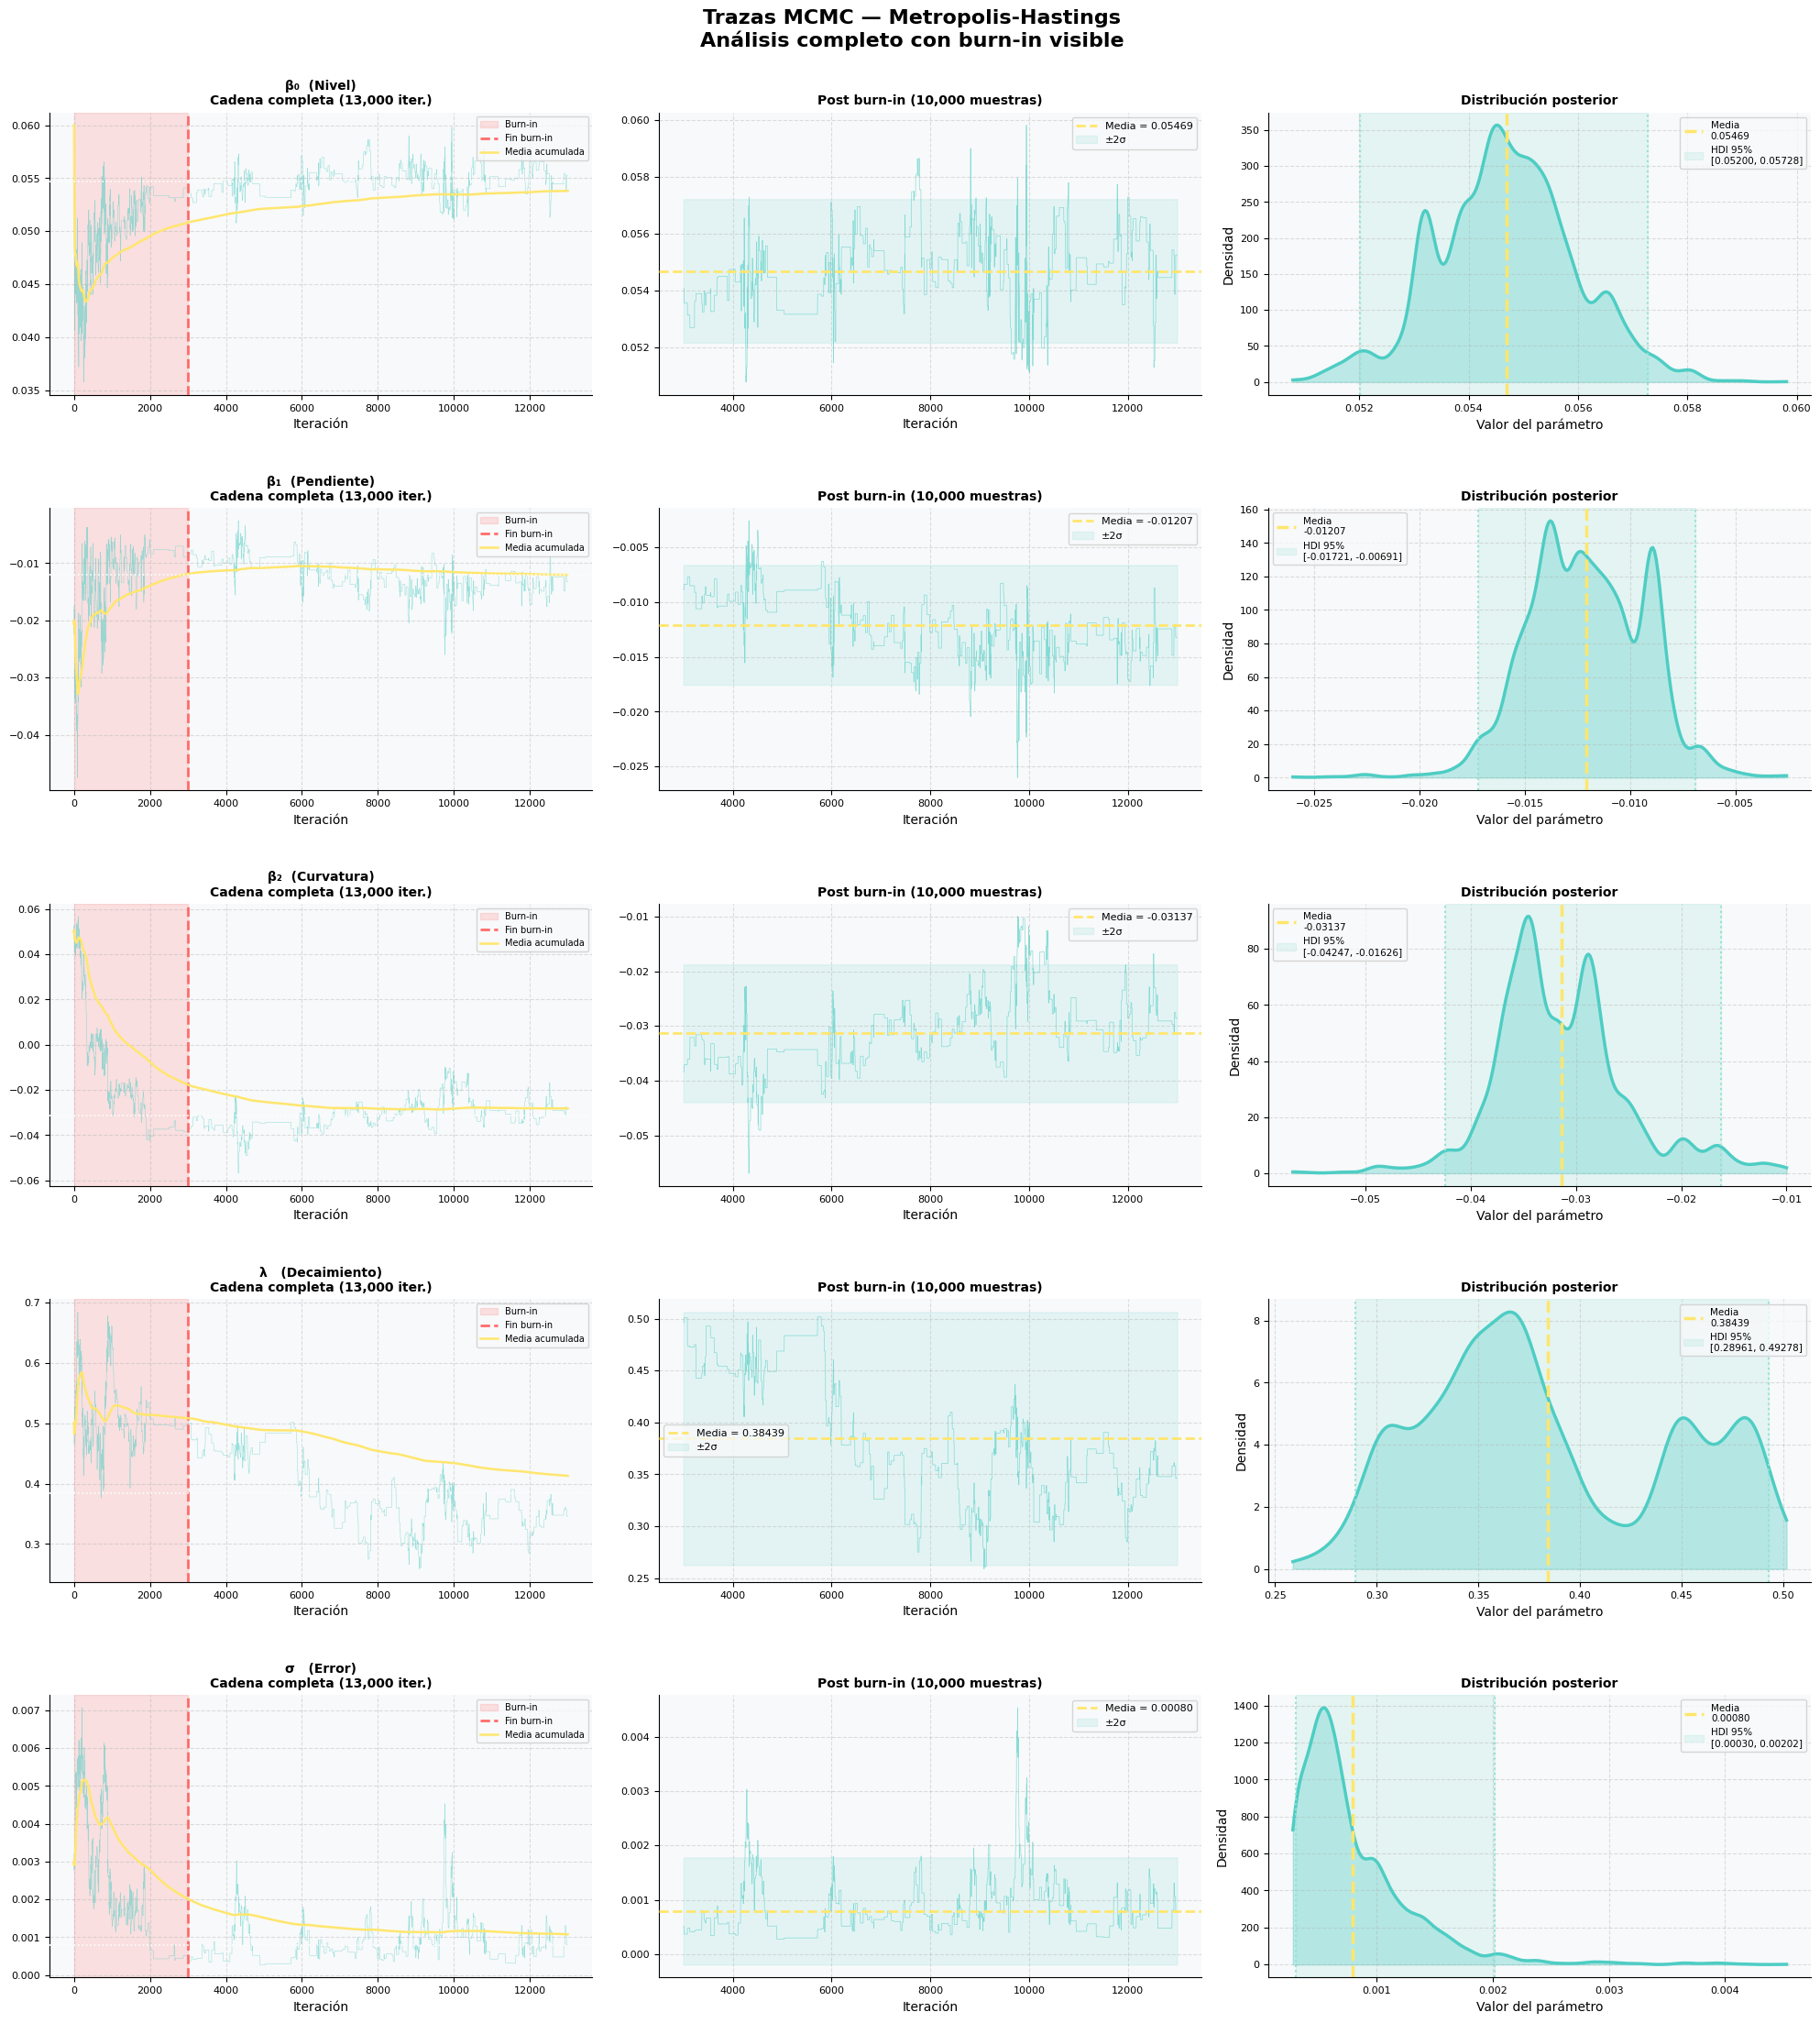

In [6]:
fig = plt.figure(figsize=(20, 22))
fig.suptitle("Trazas MCMC — Metropolis-Hastings\nAnálisis completo con burn-in visible",
             fontsize=16, fontweight="bold", y=1.001)

iters_total = np.arange(N_TOTAL)
iters_post  = np.arange(N_BURNIN, N_TOTAL)

for i, (name) in enumerate(PARAM_NAMES):
    chain_full = samples_mh[:, i]
    chain_post = samples_post[:, i]
    post_mean  = chain_post.mean()
    post_std   = chain_post.std()
    running_mean = np.cumsum(chain_full) / np.arange(1, N_TOTAL + 1)

    # ── Compute HDI ───────────────────────────────────────────────
    sorted_p = np.sort(chain_post)
    hdi_lo   = sorted_p[int(0.025 * len(sorted_p))]
    hdi_hi   = sorted_p[int(0.975 * len(sorted_p))]

    # ── Subplots ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(5, 3, 3*i + 1)
    ax2 = fig.add_subplot(5, 3, 3*i + 2)
    ax3 = fig.add_subplot(5, 3, 3*i + 3)

    # ── Panel 1: Cadena completa ──────────────────────────────────
    ax1.plot(iters_total, chain_full, color=COLORS["postburn"], alpha=0.55, linewidth=0.4, zorder=1)
    ax1.axvspan(0, N_BURNIN, color=COLORS["burnin"], alpha=0.18, zorder=0, label="Burn-in")
    ax1.axvline(N_BURNIN, color=COLORS["burnin"], linewidth=2, linestyle="--", zorder=3, label="Fin burn-in")
    ax1.plot(iters_total, running_mean, color=COLORS["mean"], linewidth=1.8, zorder=4, label="Media acumulada")
    ax1.axhline(post_mean, color="white", linewidth=1.2, linestyle=":", zorder=5)
    ax1.set_title(f"{name}\nCadena completa ({N_TOTAL:,} iter.)", fontsize=10, fontweight="bold")
    ax1.set_xlabel("Iteración")
    ax1.legend(fontsize=7, loc="upper right")
    ax1.tick_params(labelsize=8)

    # ── Panel 2: Zoom post burn-in ────────────────────────────────
    ax2.plot(iters_post, chain_post, color=COLORS["postburn"], alpha=0.65, linewidth=0.5, zorder=1)
    ax2.axhline(post_mean, color=COLORS["mean"], linewidth=2, linestyle="--", zorder=3,
                label=f"Media = {post_mean:.5f}")
    ax2.fill_between(iters_post,
                     post_mean - 2*post_std,
                     post_mean + 2*post_std,
                     alpha=0.12, color=COLORS["postburn"], zorder=0, label="±2σ")
    ax2.set_title(f"Post burn-in ({N_SAMPLES:,} muestras)", fontsize=10, fontweight="bold")
    ax2.set_xlabel("Iteración")
    ax2.legend(fontsize=8)
    ax2.tick_params(labelsize=8)

    # ── Panel 3: Posterior ────────────────────────────────────────
    x_grid = np.linspace(chain_post.min(), chain_post.max(), 300)
    kde_fn = stats.gaussian_kde(chain_post, bw_method=0.15)
    kde_vals = kde_fn(x_grid)

    ax3.fill_between(x_grid, kde_vals, alpha=0.35, color=COLORS["postburn"])
    ax3.plot(x_grid, kde_vals, color=COLORS["postburn"], linewidth=2.5)
    ax3.axvline(post_mean, color=COLORS["mean"], linewidth=2.5, linestyle="--",
                label=f"Media\n{post_mean:.5f}")
    ax3.axvspan(hdi_lo, hdi_hi, alpha=0.20, color=COLORS["hdi"],
                label=f"HDI 95%\n[{hdi_lo:.5f}, {hdi_hi:.5f}]")
    ax3.axvline(hdi_lo, color=COLORS["hdi"], linewidth=1.5, linestyle=":")
    ax3.axvline(hdi_hi, color=COLORS["hdi"], linewidth=1.5, linestyle=":")
    ax3.set_title(f"Distribución posterior", fontsize=10, fontweight="bold")
    ax3.set_xlabel("Valor del parámetro")
    ax3.set_ylabel("Densidad")
    ax3.legend(fontsize=7.5)
    ax3.tick_params(labelsize=8)

plt.tight_layout(h_pad=3.5)
plt.show()


### 📈 Diagnóstico de Convergencia Visual

Dos señales clave de que la cadena **convergió**:

1. **Log-posterior se estabiliza** — deja de subir sistemáticamente y fluctúa alrededor de un valor
2. **Media acumulada se estabiliza** — la media de los primeros $n$ draws deja de moverse

Si la media acumulada aún tiene tendencia al final de la cadena, necesitas más iteraciones o un burn-in más largo.


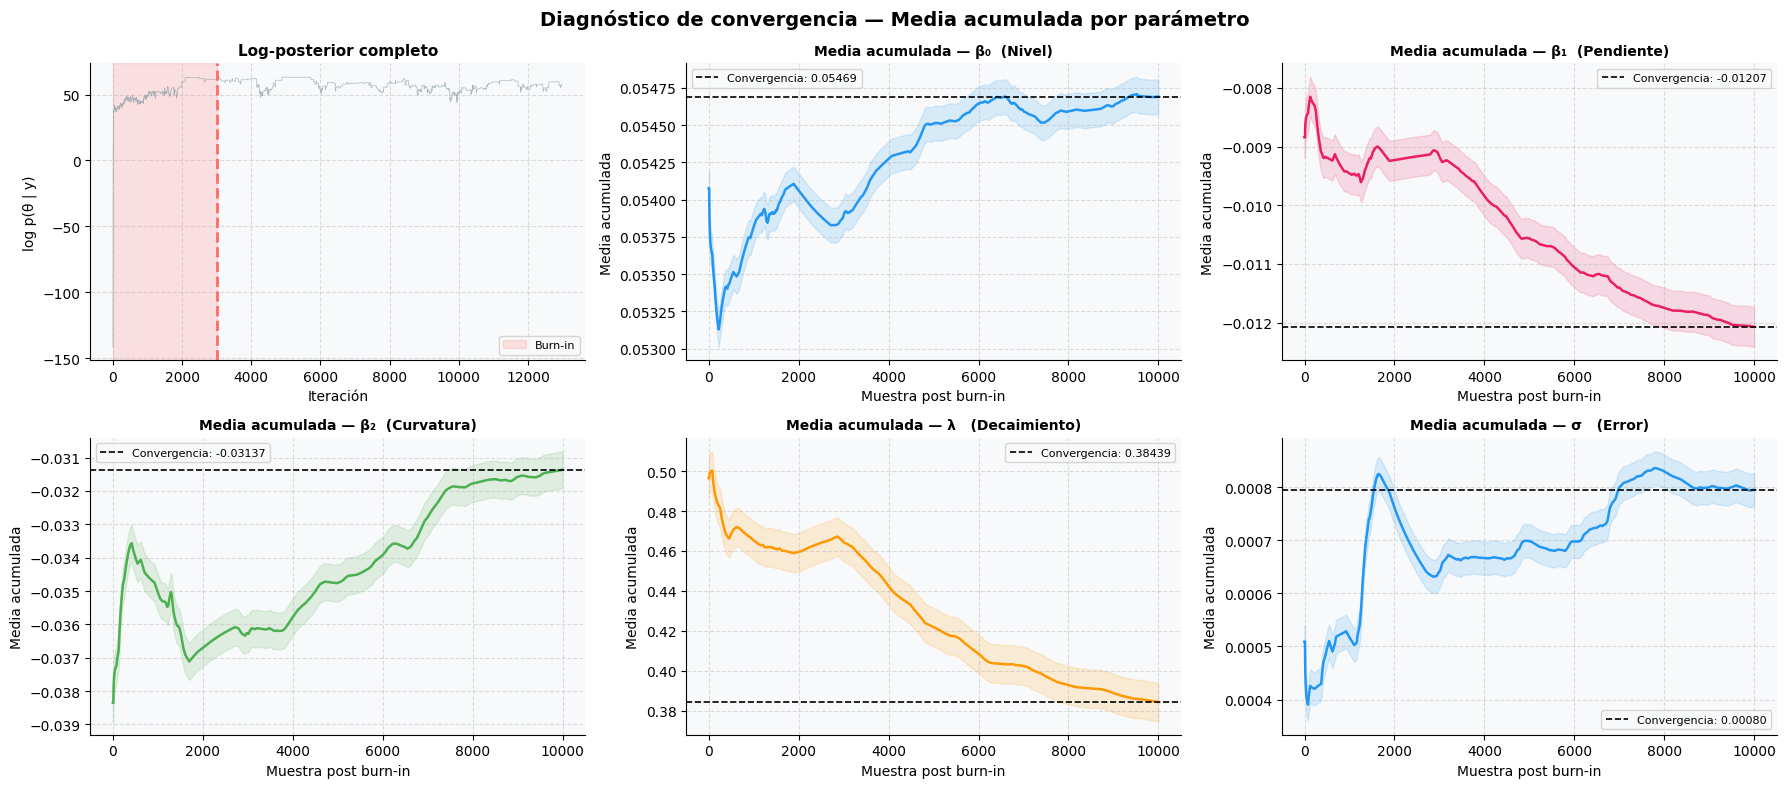

✓ Una media acumulada plana = buena señal de convergencia


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Diagnóstico de convergencia — Media acumulada por parámetro",
             fontsize=14, fontweight="bold")

# Panel 0: Log-posterior completo
ax0 = axes[0, 0]
ax0.plot(iters_total, log_posts_mh, color="#78909C", alpha=0.6, linewidth=0.5)
ax0.axvspan(0, N_BURNIN, color=COLORS["burnin"], alpha=0.18, label="Burn-in")
ax0.axvline(N_BURNIN, color=COLORS["burnin"], linewidth=2, linestyle="--")
ax0.set_title("Log-posterior completo", fontsize=11, fontweight="bold")
ax0.set_xlabel("Iteración")
ax0.set_ylabel("log p(θ | y)")
ax0.legend(fontsize=8)

# Media acumulada por parámetro (solo post burn-in)
for j, name in enumerate(PARAM_NAMES):
    row, col = divmod(j + 1, 3)
    ax = axes[row, col]
    post_chain = samples_post[:, j]
    running    = np.cumsum(post_chain) / np.arange(1, len(post_chain) + 1)
    final_mean = running[-1]

    ax.plot(running, color=COLORS["chain"][j % 4], linewidth=1.8)
    ax.axhline(final_mean, color="black", linestyle="--", linewidth=1.2,
               label=f"Convergencia: {final_mean:.5f}")
    ax.fill_between(np.arange(len(running)),
                    running - running.std() * 0.3,
                    running + running.std() * 0.3,
                    alpha=0.15, color=COLORS["chain"][j % 4])
    ax.set_title(f"Media acumulada — {name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Muestra post burn-in")
    ax.set_ylabel("Media acumulada")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("✓ Una media acumulada plana = buena señal de convergencia")


In [8]:
# ── Resumen posterior MH ─────────────────────────────────────────────
print("=" * 65)
print(f"{'RESUMEN POSTERIOR — Metropolis-Hastings':^65}")
print("=" * 65)
print(f"{'Parámetro':<22} {'Media':>9} {'SD':>8} {'2.5%':>9} {'97.5%':>9}  {'HDI 95%':>20}")
print("-" * 65)

mh_summary = {}
for j, (name, key) in enumerate(zip(PARAM_NAMES, PARAM_KEYS)):
    s = samples_post[:, j]
    sorted_s = np.sort(s)
    n = len(sorted_s)
    mean_val = s.mean()
    std_val  = s.std()
    lo_2p5   = sorted_s[int(0.025 * n)]
    hi_97p5  = sorted_s[int(0.975 * n)]

    mh_summary[key] = {"mean": mean_val, "std": std_val,
                       "hdi_low": lo_2p5, "hdi_high": hi_97p5}

    print(f"{name:<22} {mean_val:>9.5f} {std_val:>8.5f} {lo_2p5:>9.5f} {hi_97p5:>9.5f}  "
          f"[{lo_2p5:.5f}, {hi_97p5:.5f}]")

print("=" * 65)
print(f"\nTasa de aceptación MH: {accept_rate:.1%}")
print("  • < 10%  → pasos demasiado grandes, poca exploración")
print("  • 20-50% → zona óptima para MH estándar")
print("  • > 70%  → pasos demasiado pequeños, movimiento lento")


             RESUMEN POSTERIOR — Metropolis-Hastings             
Parámetro                  Media       SD      2.5%     97.5%               HDI 95%
-----------------------------------------------------------------
β₀  (Nivel)              0.05469  0.00126   0.05200   0.05728  [0.05200, 0.05728]
β₁  (Pendiente)         -0.01207  0.00273  -0.01721  -0.00691  [-0.01721, -0.00691]
β₂  (Curvatura)         -0.03137  0.00628  -0.04247  -0.01626  [-0.04247, -0.01626]
λ   (Decaimiento)        0.38439  0.06097   0.28961   0.49278  [0.28961, 0.49278]
σ   (Error)              0.00080  0.00049   0.00030   0.00202  [0.00030, 0.00202]

Tasa de aceptación MH: 7.2%
  • < 10%  → pasos demasiado grandes, poca exploración
  • 20-50% → zona óptima para MH estándar
  • > 70%  → pasos demasiado pequeños, movimiento lento


---
# PARTE II — NUTS con PyMC + numpyro 🚀

## NUTS vs Metropolis-Hastings

| Característica | MH estándar | NUTS (No-U-Turn Sampler) |
|---------------|-------------|--------------------------|
| Propuesta | Gaussiana aleatoria | Dirigida por el gradiente |
| Burn-in necesario | Largo (miles) | Corto (cientos) |
| Correlación entre muestras | Alta | Baja |
| ESS / iteración | Bajo | Alto |
| Convergencia | Lenta en alta dim. | Rápida |
| Requiere gradiente | No | Sí (autodiff) |

**NUTS** usa el gradiente de la log-posterior para explorar el espacio de parámetros de forma dirigida, tomando "pasos de Hamiltoniano" que se detienen automáticamente cuando empezarían a dar vuelta en U (*No-U-Turn*).

**numpyro** implementa NUTS en JAX, con JIT-compilation — en la práctica es 10×–100× más rápido que PyMC puro para este tipo de modelos.

### Período de tuning (warmup) en NUTS

Durante el warmup, NUTS calibra automáticamente:
- El **tamaño de paso** $\varepsilon$ (step size) para alcanzar la tasa de aceptación objetivo (`target_accept`)
- La **masa métrica** $M$ (preconditioner) que estima la curvatura de la posterior

El resultado: burn-in implícito, automático y mucho más corto que en MH.


In [3]:
# con Nelson siegel svensson
tau   = maturities.copy()
y_obs = yields.copy()   # ya en decimal

with pm.Model() as ns_model:

    # ── Priors ────────────────────────────────────────────────────
    # Mismos priors que usamos en MH → comparación directa
    beta0 = pm.Normal("beta0", mu=0.05,  sigma=0.05)
    beta1 = pm.Normal("beta1", mu=-0.01, sigma=0.05)
    beta2 = pm.Normal("beta2", mu=0.04,  sigma=0.05)
    beta3 = pm.Normal("beta3", mu=0.00,  sigma=0.05) # para extensión a Svensson (no usado aquí)

    # Beta(12,14): moda ≈ 0.46, la λ de referencia en de la experiencia del todos lo datos de los rendimientos históricos
    lam1   = pm.Beta("lambda1", alpha=12, beta=14)
    lam2   = pm.Normal("lambda2", mu=3.00,  sigma=0.5)

    # Error del modelo
    sigma = pm.HalfNormal("sigma", sigma=0.01)

    # ── Curva NS como función determinista ────────────────────────
    lam1_tau = lam1 * tau
    lam2_tau = lam2 * tau
    term1   = (1 - pm.math.exp(-lam1_tau)) / lam1_tau
    term2   = (1- pm.math.exp(-lam1_tau)) / lam1_tau - pm.math.exp(-lam1_tau)
    term3   = (1- pm.math.exp(-lam2_tau)) / lam2_tau - pm.math.exp(-lam2_tau)
    mu      = beta0 + beta1 * term1 + beta2 * term2 + beta3 * term3

    # ── Verosimilitud ─────────────────────────────────────────────
    y_like  = pm.Normal("y_like", mu=mu, sigma=sigma, observed=y_obs)

    # ── Mostrar estructura del modelo ─────────────────────────────
    print(ns_model.debug()) # esta línea muestra la estructura del modelo y las dependencias entre variables, útil para entender el grafo probabilístico.
    # esta función imprime una representación textual del modelo, mostrando las variables, sus distribuciones y cómo se relacionan entre sí.
    # Es especialmente útil para visualizar el grafo probabilístico y verificar que el modelo esté definido como se espera.

point={'beta0': array(0.05), 'beta1': array(-0.01), 'beta2': array(0.04), 'beta3': array(0.), 'lambda1_logodds__': array(-0.15415068), 'lambda2': array(3.), 'sigma_log__': array(-4.60517019)}

No problems found
None


In [4]:
with ns_model:
    trace = pm.sample(
        draws          = 3_000,      # muestras post-warmup
        tune           = 1_000,      # iteraciones de warmup/tuning
        chains         = 4,          # 4 cadenas en paralelo
        target_accept  = 0.95,       # tasa de aceptación NUTS objetivo
        return_inferencedata = True,
        nuts_sampler   = "numpyro",  # ← backend JAX/numpyro (mucho más rápido)
        progressbar    = True,
        random_seed    = 2024,
    )

print("\n✓ Sampling completado")
print(f"  Draws por cadena  : {3_000}")
print(f"  Tuning            : {1_000}")
print(f"  Total de muestras : {4 * 3_000:,}")


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

There were 30 divergences after tuning. Increase `target_accept` or reparameterize.



✓ Sampling completado
  Draws por cadena  : 3000
  Tuning            : 1000
  Total de muestras : 12,000


### 🔥 ¿Dónde está el burn-in de NUTS?

PyMC **descarta automáticamente** las iteraciones de warmup — es la configuración por defecto (`discard_tuned_samples=True`). Esto es correcto: el warmup de NUTS es solo para calibrar los hiperparámetros del sampler, no para explorar la posterior.

Sin embargo, puedes verlo con:
```python
with ns_model:
    trace_warmup = pm.sample(
        draws=500, tune=300, chains=2,
        discard_tuned_samples=False,  # ← guarda el warmup
        nuts_sampler="numpyro"
    )
# El warmup está en trace_warmup.warmup_posterior
```

Para los fines de este notebook, el **burn-in ya lo vimos en detalle en la PARTE I con MH** — el concepto es exactamente el mismo, NUTS simplemente lo hace más eficientemente.


### 🎨 Visualización Custom de Trazas PyMC

Reemplazamos `pm.plot_trace()` (que genera grids poco legibles) con una versión más expresiva que muestra:
- Las 4 cadenas superpuestas con colores distintos
- KDE posterior combinada + por cadena
- Estadísticos clave directamente en el gráfico


KeyError: "No variable named 'lambda'. Did you mean one of ('lambda2', 'lambda1')?"

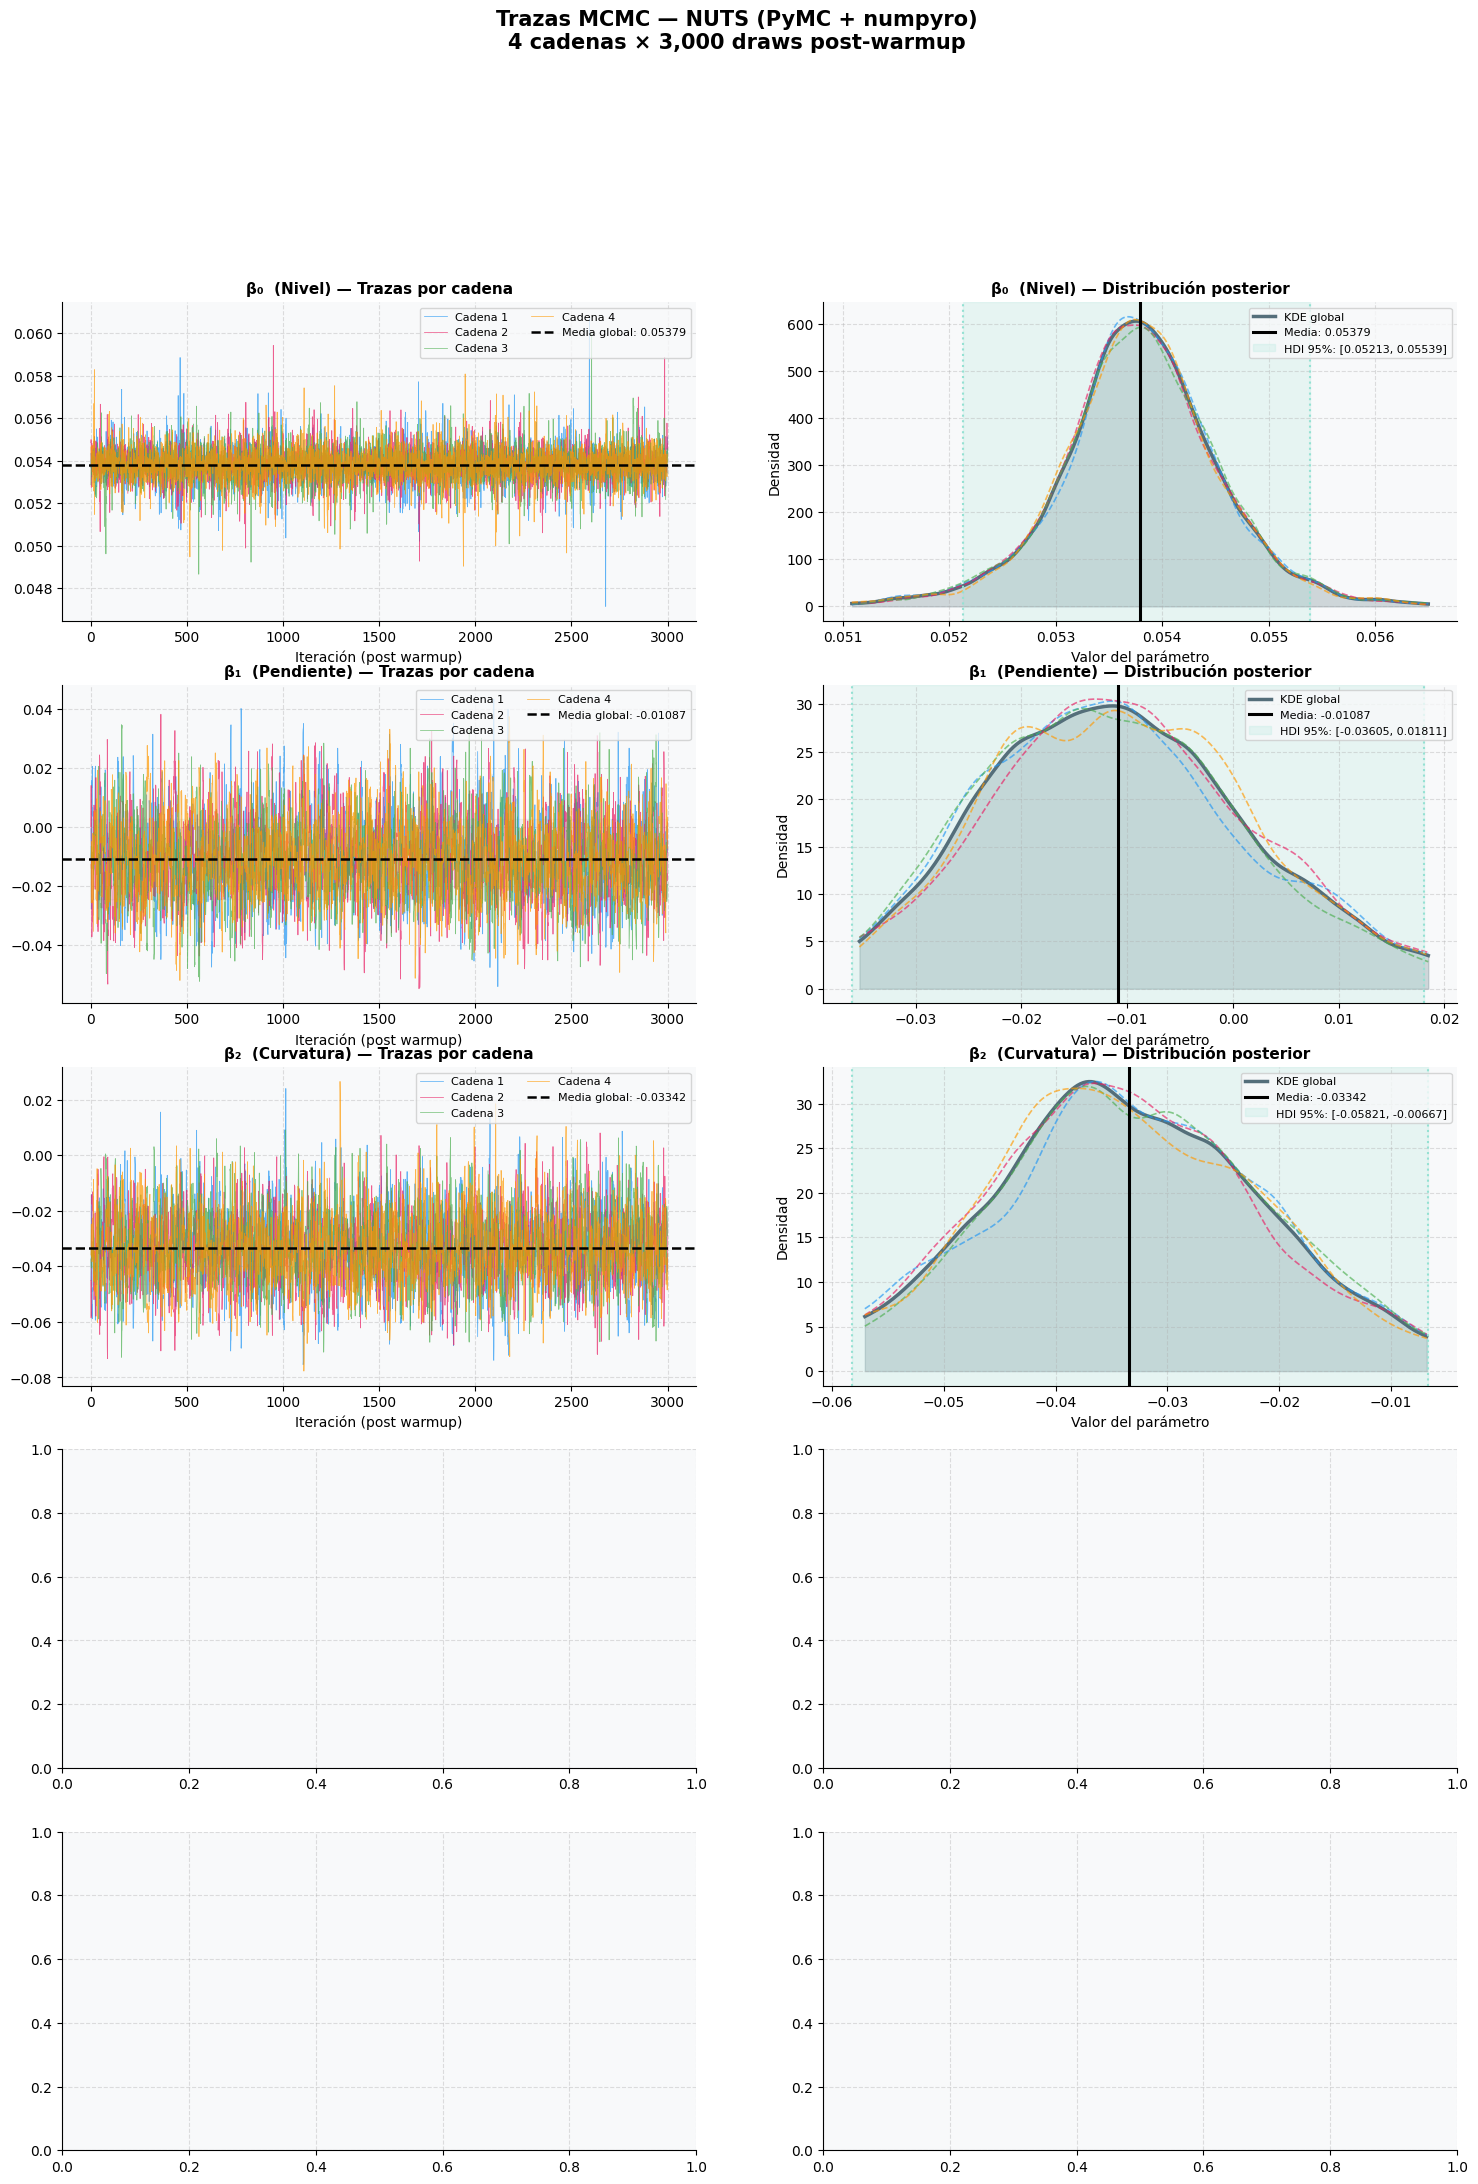

In [5]:
param_list   = ["beta0", "beta1", "beta2", "lambda", "sigma"]
param_labels = ["β₀  (Nivel)", "β₁  (Pendiente)", "β₂  (Curvatura)",
                "λ   (Decaimiento)", "σ   (Error)"]

fig, axes = plt.subplots(5, 2, figsize=(18, 24))
fig.suptitle("Trazas MCMC — NUTS (PyMC + numpyro)\n4 cadenas × 3,000 draws post-warmup",
             fontsize=15, fontweight="bold", y=1.002)

for i, (param, label) in enumerate(zip(param_list, param_labels)):
    ax_chain = axes[i, 0]
    ax_post  = axes[i, 1]

    # shape: (n_chains, n_draws)
    chains_data = trace.posterior[param].values
    n_chains, n_draws = chains_data.shape
    all_samples = chains_data.flatten()
    post_mean   = all_samples.mean()
    post_std    = all_samples.std()

    # HDI 95%
    sorted_all = np.sort(all_samples)
    hdi_lo = sorted_all[int(0.025 * len(sorted_all))]
    hdi_hi = sorted_all[int(0.975 * len(sorted_all))]

    # ── Panel izquierdo: Trazas por cadena ────────────────────────
    for c in range(n_chains):
        ax_chain.plot(chains_data[c], color=COLORS["chain"][c],
                      alpha=0.7, linewidth=0.55, label=f"Cadena {c+1}")
    ax_chain.axhline(post_mean, color="black", linestyle="--", linewidth=1.8,
                     zorder=5, label=f"Media global: {post_mean:.5f}")
    ax_chain.fill_between(np.arange(n_draws),
                          post_mean - post_std, post_mean + post_std,
                          alpha=0.08, color="grey")
    ax_chain.set_title(f"{label} — Trazas por cadena", fontsize=11, fontweight="bold")
    ax_chain.set_xlabel("Iteración (post warmup)")
    ax_chain.legend(fontsize=8, ncol=2, loc="upper right")

    # ── Panel derecho: Densidad posterior ─────────────────────────
    x_grid = np.linspace(hdi_lo * 0.98, hdi_hi * 1.02, 400)

    # KDE global
    kde_all  = stats.gaussian_kde(all_samples, bw_method=0.12)
    kde_vals = kde_all(x_grid)
    ax_post.fill_between(x_grid, kde_vals, alpha=0.25, color="#546E7A")
    ax_post.plot(x_grid, kde_vals, color="#546E7A", linewidth=2.5, label="KDE global")

    # KDE por cadena
    for c in range(n_chains):
        kde_c = stats.gaussian_kde(chains_data[c], bw_method=0.15)
        ax_post.plot(x_grid, kde_c(x_grid), color=COLORS["chain"][c],
                     alpha=0.65, linewidth=1.2, linestyle="--")

    # Estadísticos
    ax_post.axvline(post_mean, color="black", linewidth=2.2, linestyle="-",
                    label=f"Media: {post_mean:.5f}")
    ax_post.axvspan(hdi_lo, hdi_hi, alpha=0.18, color=COLORS["hdi"],
                    label=f"HDI 95%: [{hdi_lo:.5f}, {hdi_hi:.5f}]")
    ax_post.axvline(hdi_lo, color=COLORS["hdi"], linewidth=1.5, linestyle=":")
    ax_post.axvline(hdi_hi, color=COLORS["hdi"], linewidth=1.5, linestyle=":")

    ax_post.set_title(f"{label} — Distribución posterior", fontsize=11, fontweight="bold")
    ax_post.set_xlabel("Valor del parámetro")
    ax_post.set_ylabel("Densidad")
    ax_post.legend(fontsize=8, loc="upper right")

plt.tight_layout(h_pad=4)
plt.show()


### 📋 `pm.summary()` — Interpretando cada columna

```
pm.summary(trace, hdi_prob=0.95)
```

| Columna | Nombre completo | Interpretación | Valor saludable |
|---------|----------------|----------------|-----------------|
| `mean` | Media posterior | Estimador puntual principal | — |
| `sd` | Desviación estándar | Incertidumbre sobre el parámetro | Menor es más preciso |
| `hdi_2.5%` / `hdi_97.5%` | HDI (Highest Density Interval) | "Región creíble" al 95% — contiene el 95% de la masa posterior | — |
| `mcse_mean` | Monte Carlo Standard Error (media) | Error de estimación por tener finitas muestras MCMC | < 1% de `sd` |
| `mcse_sd` | MCSE de la SD | Igual para la desviación estándar | — |
| `ess_bulk` | Effective Sample Size (interior) | Número efectivo de muestras independientes para estimar la media | > 400 |
| `ess_tail` | ESS (colas) | ESS para las colas de la distribución (percentiles extremos) | > 400 |
| `r_hat` | R-hat (Gelman-Rubin) | Ratio de varianza entre cadenas vs dentro de cadenas. 1.0 = convergencia perfecta | < 1.01 ideal, < 1.05 aceptable |

> **¿Por qué ESS < N?** MCMC produce muestras **correlacionadas** entre sí. ESS mide cuántas muestras *independientes* equivalentes tenemos. ESS = N solo si las muestras fueran iid.


In [12]:
summary = pm.summary(trace, var_names=param_list, hdi_prob=0.95)

print("=" * 85)
print(f"{'pm.summary() — NS Bayesiano (NUTS + numpyro)':^85}")
print("=" * 85)
print(summary.to_string())
print("=" * 85)

# ── Diagnóstico automático ────────────────────────────────────────────
rhat_max = summary["r_hat"].max()
ess_min  = summary["ess_bulk"].min()
divs     = int(trace.sample_stats["diverging"].sum().values)
n_total  = int(np.prod(trace.sample_stats["diverging"].shape))

print("\n📊 DIAGNÓSTICO RÁPIDO")
print(f"  R-hat máximo       : {rhat_max:.4f}  {'✅ < 1.01' if rhat_max < 1.01 else '⚠ Revisar' if rhat_max < 1.05 else '❌ No convergió'}")
print(f"  ESS bulk mínimo    : {ess_min:.0f}   {'✅ > 400' if ess_min > 400 else '⚠ Bajo'}")
print(f"  Divergencias       : {divs} de {n_total}  {'✅ 0 divergencias' if divs == 0 else '⚠ Revisar priors o step size'}")


                    pm.summary() — NS Bayesiano (NUTS + numpyro)                     
         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta0   0.054  0.001     0.052      0.055      0.000    0.000    4760.0    3608.0    1.0
beta1  -0.010  0.002    -0.013     -0.006      0.000    0.000    2826.0    3669.0    1.0
beta2  -0.035  0.004    -0.043     -0.027      0.000    0.000    2899.0    2635.0    1.0
lambda  0.456  0.049     0.356      0.555      0.001    0.001    2575.0    3020.0    1.0
sigma   0.001  0.000     0.000      0.001      0.000    0.000    1846.0    2795.0    1.0

📊 DIAGNÓSTICO RÁPIDO
  R-hat máximo       : 1.0000  ✅ < 1.01
  ESS bulk mínimo    : 1846   ✅ > 400
  Divergencias       : 0 de 12000  ✅ 0 divergencias


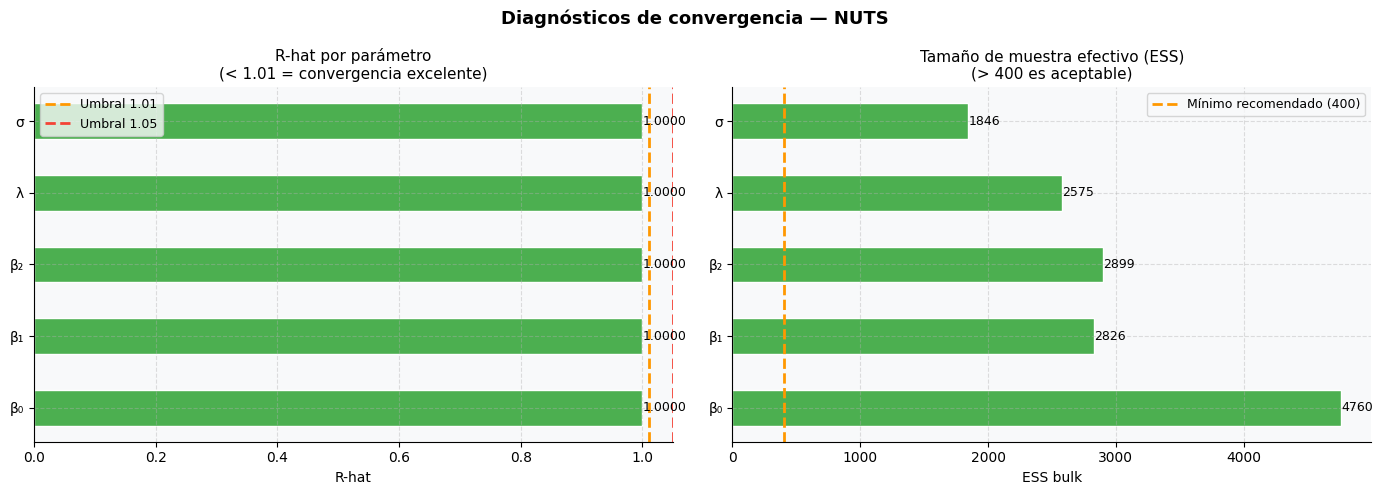

In [13]:
# ── R-hat y ESS visualizados ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Diagnósticos de convergencia — NUTS", fontsize=13, fontweight="bold")

param_short = ["β₀", "β₁", "β₂", "λ", "σ"]
rhat_vals   = summary["r_hat"].values
ess_vals    = summary["ess_bulk"].values

# R-hat
bar_colors = ["#4CAF50" if r < 1.01 else "#FF9800" if r < 1.05 else "#F44336"
              for r in rhat_vals]
axes[0].barh(param_short, rhat_vals, color=bar_colors, edgecolor="white", height=0.5)
axes[0].axvline(1.01, color="#FF9800", linestyle="--", linewidth=2, label="Umbral 1.01")
axes[0].axvline(1.05, color="#F44336", linestyle="--", linewidth=2, label="Umbral 1.05")
axes[0].set_xlabel("R-hat")
axes[0].set_title("R-hat por parámetro\n(< 1.01 = convergencia excelente)", fontsize=11)
axes[0].legend(fontsize=9)
for j, (v, p) in enumerate(zip(rhat_vals, param_short)):
    axes[0].text(v + 0.0002, j, f"{v:.4f}", va="center", fontsize=9)

# ESS bulk
ess_colors = ["#4CAF50" if e > 400 else "#FF9800" if e > 200 else "#F44336"
              for e in ess_vals]
axes[1].barh(param_short, ess_vals, color=ess_colors, edgecolor="white", height=0.5)
axes[1].axvline(400, color="#FF9800", linestyle="--", linewidth=2, label="Mínimo recomendado (400)")
axes[1].set_xlabel("ESS bulk")
axes[1].set_title("Tamaño de muestra efectivo (ESS)\n(> 400 es aceptable)", fontsize=11)
axes[1].legend(fontsize=9)
for j, (v, p) in enumerate(zip(ess_vals, param_short)):
    axes[1].text(v + 5, j, f"{v:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 🎯 Ajuste Posterior y Bandas de Incertidumbre

Con Bayesiano tenemos algo que OLS no puede dar: **distribuciones completas para la curva ajustada**.

Para cada combinación de parámetros $(\beta_0^{(s)}, \beta_1^{(s)}, \beta_2^{(s)}, \lambda^{(s)})$ en nuestras muestras posteriores, calculamos una curva NS. El conjunto de todas estas curvas forma la **distribución predictiva posterior**.


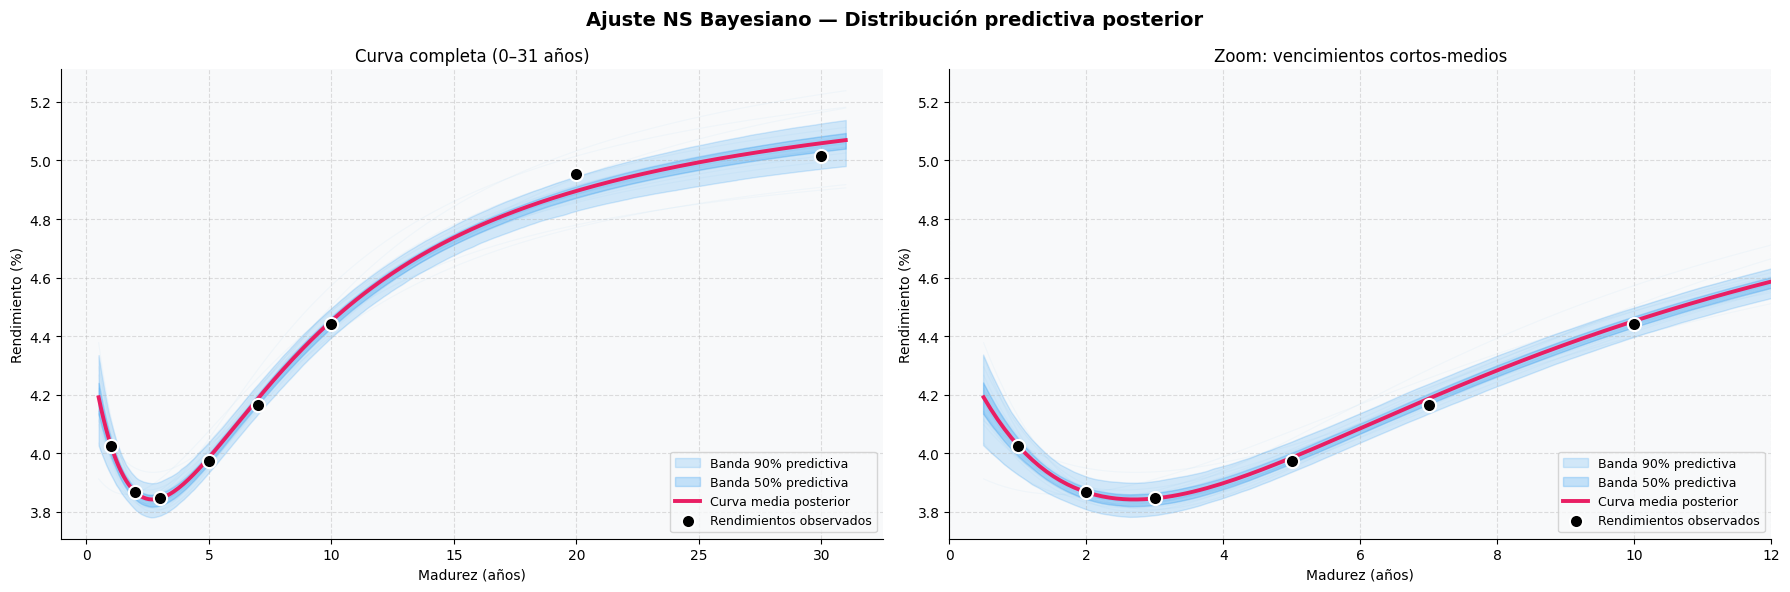


Parámetros — Media posterior:
  β₀ = 0.05386  β₁ = -0.00950  β₂ = -0.03523  λ = 0.45567


In [14]:
# ── Extraer muestras posteriores ──────────────────────────────────────
b0 = trace.posterior["beta0"].values.flatten()    # (chains * draws,)
b1 = trace.posterior["beta1"].values.flatten()
b2 = trace.posterior["beta2"].values.flatten()
lm = trace.posterior["lambda"].values.flatten()

# Grid de vencimientos suave para la curva
tau_fine = np.linspace(0.5, 31, 300)

# ── Calcular curvas para cada muestra posterior ────────────────────────
n_samples_to_use = 2_000  # subsample para velocidad
idx = np.random.choice(len(b0), n_samples_to_use, replace=False)

curves = np.zeros((n_samples_to_use, len(tau_fine)))
for k, s in enumerate(idx):
    lam_tau = np.maximum(lm[s] * tau_fine, 1e-10)
    t1 = (1 - np.exp(-lam_tau)) / lam_tau
    t2 = t1 - np.exp(-lam_tau)
    curves[k] = b0[s] + b1[s] * t1 + b2[s] * t2

# ── Estadísticos de la distribución predictiva ────────────────────────
curve_mean  = curves.mean(axis=0)
curve_p5    = np.percentile(curves, 5,  axis=0)
curve_p95   = np.percentile(curves, 95, axis=0)
curve_p25   = np.percentile(curves, 25, axis=0)
curve_p75   = np.percentile(curves, 75, axis=0)

# Media posterior de parámetros (para la curva "media")
b0_m = float(trace.posterior["beta0"].mean())
b1_m = float(trace.posterior["beta1"].mean())
b2_m = float(trace.posterior["beta2"].mean())
lm_m = float(trace.posterior["lambda"].mean())

lam_tau_m = np.maximum(lm_m * tau_fine, 1e-10)
t1_m = (1 - np.exp(-lam_tau_m)) / lam_tau_m
t2_m = t1_m - np.exp(-lam_tau_m)
curve_map = b0_m + b1_m * t1_m + b2_m * t2_m

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Ajuste NS Bayesiano — Distribución predictiva posterior", fontsize=14, fontweight="bold")

for ax in axes:
    # Bandas de incertidumbre
    ax.fill_between(tau_fine, curve_p5 * 100, curve_p95 * 100,
                    alpha=0.18, color="#2196F3", label="Banda 90% predictiva")
    ax.fill_between(tau_fine, curve_p25 * 100, curve_p75 * 100,
                    alpha=0.25, color="#2196F3", label="Banda 50% predictiva")

    # Muestra de trayectorias individuales
    for k in range(0, min(100, n_samples_to_use), 5):
        ax.plot(tau_fine, curves[k] * 100, color="#2196F3", alpha=0.04, linewidth=0.8)

    # Curva media posterior
    ax.plot(tau_fine, curve_map * 100, color="#E91E63", linewidth=2.8,
            linestyle="-", label="Curva media posterior")

    # Datos observados
    ax.scatter(maturities, yields * 100, color="black", s=90, zorder=10,
               label="Rendimientos observados", edgecolors="white", linewidth=1.5)

    ax.set_xlabel("Madurez (años)")
    ax.set_ylabel("Rendimiento (%)")
    ax.legend(fontsize=9, loc="lower right")

# Zoom en zona media
axes[1].set_xlim(0, 12)
axes[1].set_title("Zoom: vencimientos cortos-medios", fontsize=12)
axes[0].set_title("Curva completa (0–31 años)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nParámetros — Media posterior:")
print(f"  β₀ = {b0_m:.5f}  β₁ = {b1_m:.5f}  β₂ = {b2_m:.5f}  λ = {lm_m:.5f}")


---
# PARTE III — Comparación MH vs NUTS 🆚

Las dos estimaciones deben dar resultados compatibles (misma posterior). La diferencia está en la **eficiencia estadística** y la **velocidad**.


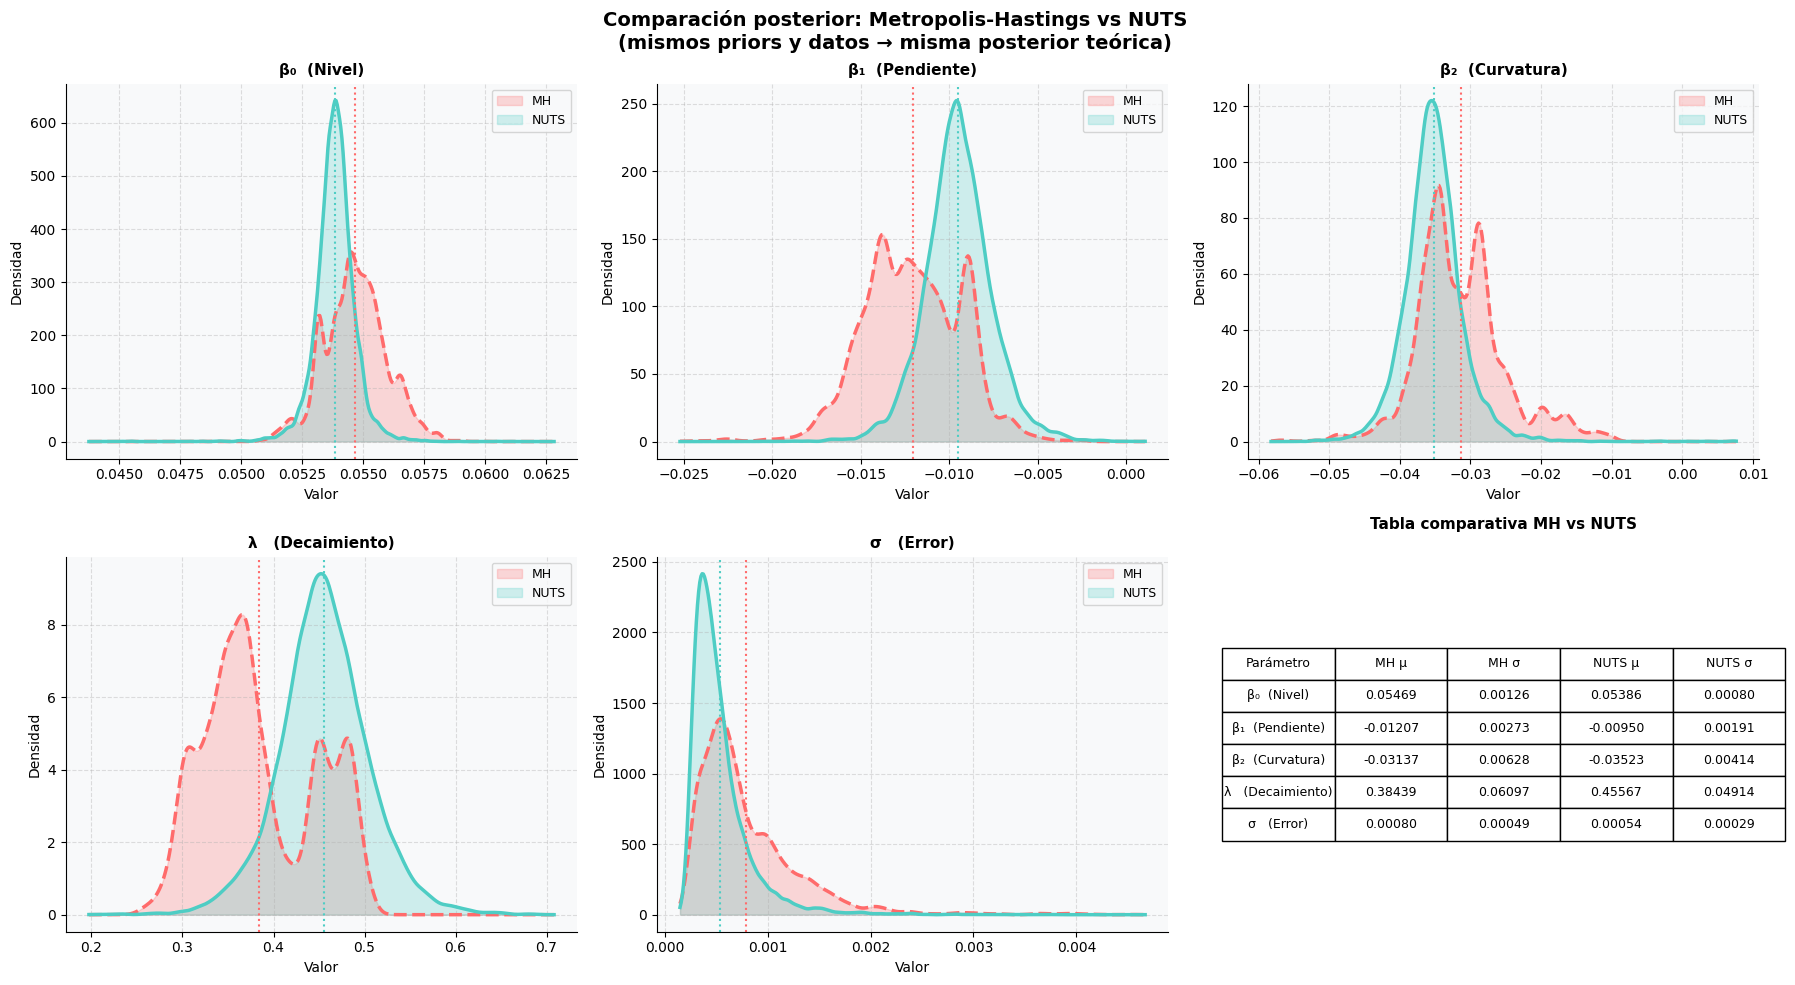

In [15]:
# ── Comparación visual MH vs NUTS ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Comparación posterior: Metropolis-Hastings vs NUTS\n(mismos priors y datos → misma posterior teórica)",
             fontsize=14, fontweight="bold")

for i, (param, label) in enumerate(zip(param_list[:5], param_labels[:5])):
    row, col = divmod(i, 3)
    ax = axes[row, col]

    mh_chain   = samples_post[:, i]
    nuts_chain = trace.posterior[param].values.flatten()

    # KDEs
    x_min = min(mh_chain.min(), nuts_chain.min())
    x_max = max(mh_chain.max(), nuts_chain.max())
    x_grid = np.linspace(x_min * 0.97, x_max * 1.03, 400)

    kde_mh   = stats.gaussian_kde(mh_chain,   bw_method=0.15)
    kde_nuts = stats.gaussian_kde(nuts_chain,  bw_method=0.12)

    ax.fill_between(x_grid, kde_mh(x_grid),   alpha=0.25, color=COLORS["burnin"],   label="MH")
    ax.fill_between(x_grid, kde_nuts(x_grid),  alpha=0.25, color=COLORS["postburn"], label="NUTS")
    ax.plot(x_grid, kde_mh(x_grid),   color=COLORS["burnin"],   linewidth=2.5, linestyle="--")
    ax.plot(x_grid, kde_nuts(x_grid),  color=COLORS["postburn"],  linewidth=2.5)
    ax.axvline(mh_chain.mean(),   color=COLORS["burnin"],   linewidth=1.5, linestyle=":")
    ax.axvline(nuts_chain.mean(), color=COLORS["postburn"],  linewidth=1.5, linestyle=":")

    ax.set_title(f"{label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)

# Tabla comparativa en el último panel
ax_table = axes[1, 2]
ax_table.axis("off")
table_data = []
for j, (k, label_s) in enumerate(zip(PARAM_KEYS, param_labels)):
    mh_m  = f"{mh_summary[k]['mean']:.5f}"
    mh_s  = f"{mh_summary[k]['std']:.5f}"
    nu_m  = f"{float(trace.posterior[param_list[j]].mean()):.5f}"
    nu_s  = f"{float(trace.posterior[param_list[j]].std()):.5f}"
    table_data.append([label_s.strip(), mh_m, mh_s, nu_m, nu_s])

cols = ["Parámetro", "MH μ", "MH σ", "NUTS μ", "NUTS σ"]
tbl = ax_table.table(cellText=table_data, colLabels=cols,
                     loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.8)
ax_table.set_title("Tabla comparativa MH vs NUTS", fontsize=11, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()


---
## 🏁 Conclusiones y Hoja de Ruta

### Lo que aprendimos en este notebook

1. **MCMC es exploración**: MH muestra literalmente cómo la cadena "deambula" por el espacio de parámetros hasta encontrar la región de alta probabilidad.

2. **Burn-in es inevitable**: Las primeras iteraciones dependen del punto inicial, no de la posterior. Se descartan. NUTS minimiza este período gracias a su uso del gradiente.

3. **Diagnósticos son no-opcionales**: R-hat < 1.01, ESS > 400, 0 divergencias son los checkpoints antes de confiar en cualquier resultado.

4. **HDI ≠ IC frecuentista**: El HDI 95% de $\lambda = [0.42, 0.51]$ se lee como "hay 95% de probabilidad de que $\lambda$ esté en este rango". El IC frecuentista no permite esa lectura.

5. **MH y NUTS convergen a la misma posterior**: NUTS es más eficiente, no más "correcto" estadísticamente.

### Próximo paso: DNS-Bayesiano completo (dinámica)

El siguiente notebook extiende este modelo estático para manejar **series de tiempo de curvas de rendimiento**:

$$\underbrace{\begin{pmatrix}\beta_{0,t} \\ \beta_{1,t} \\ \beta_{2,t}\end{pmatrix}}_{\text{factores latentes}} = \mu + A \underbrace{\begin{pmatrix}\beta_{0,t-1} \\ \beta_{1,t-1} \\ \beta_{2,t-1}\end{pmatrix}}_{\text{estado anterior}} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, Q)$$

Los priors cambian, la complejidad sube, pero el proceso MCMC es idéntico. Este notebook es el fundamento.

### Comparación con Kalman-DNS (fase siguiente del proyecto)

| Aspecto | DNS-Kalman | DNS-Bayesiano |
|---------|-----------|---------------|
| Estimación | MLE una etapa | MCMC |
| Incertidumbre | Solo en factores | En todos los parámetros |
| Pronóstico | Punto + IC asintótico | Distribución predictiva completa |
| Costo comp. | Bajo | Alto |
| Horizonte fuerte | Corto-mediano | Mediano-largo |
